## Desafío

Crear un mapa coroplético con el promedio de valor de inmuebles para cada distrito de la ciudad de São Paulo e insertar tooltips con datos estadísticos.

Primeramente, vamos a importar las bibliotecas `geopandas`, `pandas` y `folium` para ejecutar el desafío.

In [1]:
import geopandas as gpd
import folium
import pandas as pd

Realizaremos la lectura de los datos:

In [2]:
datos_sp = gpd.read_file('/content/geometria_sp.shp')
estadisticas_dist = pd.read_csv('/content/estadisticas_dist_sp.csv')

Utilizaremos el método `head()` para explorar las dos bases de datos:

In [3]:
datos_sp.head()

,NM_DIST,geometry
0,Alto de Pinheiros,"POLYGON ((-46.72921 -23.54973, -46.73018 -23.5..."
1,Anhanguera,"POLYGON ((-46.80745 -23.45373, -46.80756 -23.4..."
2,Aricanduva,"POLYGON ((-46.52236 -23.58478, -46.5226 -23.58..."
3,Artur Alvim,"POLYGON ((-46.48595 -23.55433, -46.48613 -23.5..."
4,Barra Funda,"POLYGON ((-46.68561 -23.52338, -46.68563 -23.5..."


In [4]:
estadisticas_dist.head()

,NM_DIST,precio_min,precio_medio,precio_max,ct_inmuebles,area_min,area_max
0,Alto de Pinheiros,300000,1.766567e+06,3720000,21,39,310
1,Anhanguera,900000,9.000000e+05,900000,2,120,120
2,Aricanduva,235000,3.732157e+05,900000,19,45,83
3,Artur Alvim,175000,2.468407e+05,580000,27,33,153
4,Barra Funda,250000,1.080059e+06,3540000,17,42,204


El GeoDataFrame almacenado en `datos_sp` contiene la geometría y el nombre de cada distrito de São Paulo.

El DataFrame almacenado en estadisticas_dist contiene el nombre de cada distrito y las siguientes estadísticas:

Precio mínimo, promedio y máximo de los inmuebles en el distrito;
Cantidad de inmuebles en el distrito;
Área mínima y máxima de los inmuebles en el distrito.

---

Vamos a generar una visualización inicial de los distritos de São Paulo usando el método `plot()` de la biblioteca `GeoPandas`:

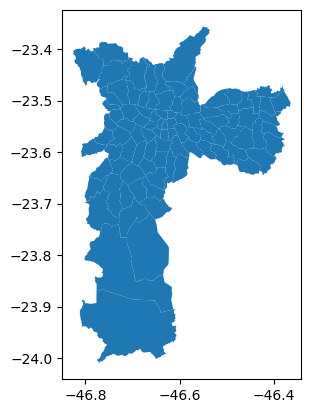

In [5]:
datos_sp.plot();

Obtuvimos los contornos de los distritos y también es posible localizar la latitud y longitud de la ciudad de São Paulo. Usaremos el valor -23.7 para la latitud y -46.6 para la longitud.  

Ahora podemos utilizar la biblioteca `Folium` para crear un mapa coroplético.  

El primer paso es generar una visualización del mapa base, centrado en -23.7 y -46.6, con un nivel de zoom inicial de 10 y la capa de visualización 'cartodbpositron'.  

Después de esto, utilizaremos el método `Choropleth()` para generar el mapa coroplético. A continuación, se explica cada uno de los principales parámetros:  

- `geo_data`: Datos geográficos obtenidos a partir del `GeoDataFrame` `dados_sp`.  
- `data`: Datos numéricos obtenidos a partir del `DataFrame` `estadisticas_dist`.  
- `columns`: Columnas utilizadas de los datos numéricos. La primera columna debe contener los nombres de los distritos, que servirán como clave para unir la información geográfica, y la segunda columna representa la información numérica que se mostrará mediante colores.  
- `key_on`: Ruta de la columna clave en los datos de geometría a partir de un archivo JSON.

In [6]:
mapa_sp = folium.Map(location = [-23.7, -46.6],
                      zoom_start = 10,
                      tiles = 'cartodbpositron')

folium.Choropleth(geo_data = datos_sp,
                  data= estadisticas_dist,
                  columns = ['NM_DIST', 'precio_medio'],
                  key_on = 'feature.properties.NM_DIST',
                  fill_color = 'YlOrRd',
                  nan_fill_color = 'white',
                  bins = 10,
                  highlight = True,
                  legend_name = 'Promedio del valor del inmueble').add_to(mapa_sp)

mapa_sp

Ahora vamos seguir con la etapa adicional del desafío, que consiste en insertar tooltips con las estadísticas de cada distrito de la ciudad de São Paulo.  

Primero, debemos agrupar la información de geometría en el conjunto de datos de estadísticas para utilizar el método `GeoJson()` con estos datos.

In [7]:
estadisticas_dist = gpd.GeoDataFrame(estadisticas_dist.merge(datos_sp, on = 'NM_DIST', how = 'left'))
estadisticas_dist

,NM_DIST,precio_min,precio_medio,precio_max,ct_inmuebles,area_min,area_max,geometry
0,Alto de Pinheiros,300000,1.766567e+06,3720000,21,39,310,"POLYGON ((-46.72921 -23.54973, -46.73018 -23.5..."
1,Anhanguera,900000,9.000000e+05,900000,2,120,120,"POLYGON ((-46.80745 -23.45373, -46.80756 -23.4..."
2,Aricanduva,235000,3.732157e+05,900000,19,45,83,"POLYGON ((-46.52236 -23.58478, -46.5226 -23.58..."
3,Artur Alvim,175000,2.468407e+05,580000,27,33,153,"POLYGON ((-46.48595 -23.55433, -46.48613 -23.5..."
4,Barra Funda,250000,1.080059e+06,3540000,17,42,204,"POLYGON ((-46.68561 -23.52338, -46.68563 -23.5..."
...,...,...,...,...,...,...,...,...
84,Vila Matilde,210000,4.394838e+05,750000,37,34,140,"POLYGON ((-46.53259 -23.54319, -46.53317 -23.5..."
85,Vila Medeiros,265000,4.041278e+05,650000,38,41,82,"POLYGON ((-46.59123 -23.49983, -46.59156 -23.4..."
86,Vila Prudente,205000,6.250302e+05,2098000,29,35,155,"POLYGON ((-46.579 -23.59952, -46.57899 -23.599..."
87,Vila Sônia,189900,8.243598e+05,3000000,50,32,420,"POLYGON ((-46.75131 -23.61098, -46.75132 -23.6..."


Ahora podemos estilizar los contornos y el relleno para destacar la región que está siendo seleccionada con el cursor del mouse y luego insertar los tooltips utilizando el método `GeoJsonTooltip()`.  

Al final, añadimos esta configuración en la parte superior de la visualización con el método `keep_in_front()` y generamos un archivo HTML de la visualización.

In [8]:
style_function = lambda x: {'fillColor': '#ffffff',
                            'color':'#000000',
                            'fillOpacity': 0.1,
                            'weight': 0.1}
highlight_function = lambda x: {'fillColor': '#000000',
                                'color':'#000000',
                                'fillOpacity': 0.5,
                                'weight': 0.1}

config = folium.features.GeoJson(
    estadisticas_dist,
    style_function = style_function,
    highlight_function= highlight_function,
    tooltip = folium.features.GeoJsonTooltip(
        fields=['NM_DIST', 'precio_min', 'precio_medio', 'precio_max', 'ct_inmuebles', 'area_min', 'area_max'],
        aliases=['Distrito: ', 'Precio mínimo: ', 'Precio medio: ', 'Precio máximo: ', 'Cantidad de inmuebles', 'Área mínima: ', 'Área máxima: '],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")

    )
)

mapa_sp.add_child(config)
mapa_sp.keep_in_front(config)

mapa_sp.save('mapa_sp.html')
mapa_sp